In [ ]:
# ===== 每次开头 =====
dir.create("/root/autodl-tmp/tmp", showmp")Warnings = FALSE, recursive = TRUE)
Sys.setenv(TMPDIR = "/root/autodl-tmp/tmp")

In [ ]:
# 先重启内核
tempdir()  # 确认路径

In [ ]:
# 读取数据
library(data.table)
dir <- "/root/autodl-tmp/DATA/R-DATA"
set1_train <- fread(file.path(dir, "set1_train.csv.gz"))
set1_test  <- fread(file.path(dir, "set1_test.csv.gz"))

In [3]:
set1 <- rbindlist(list(set1_train, set1_test), use.names = TRUE, fill = TRUE)

In [4]:
library(ggplot2)
library(grid)  

date_col <- "Trddt"   # 日期列名
bidask_vars <- c("AQsp_Amount_lag1", "AQsp_Volume_lag1", "AQsp_time_lag1")  #  bid-ask 指标列名

# -----------------------------
# 日度横截面汇聚 + 转长表（支持 median / mean）
# -----------------------------
make_daily_long <- function(dt, set_label, agg = c("median", "mean")){
  agg <- match.arg(agg)

  dt <- copy(dt)
  setDT(dt)

  dt[, (date_col) := as.IDate(get(date_col))]

  for (v in bidask_vars) dt[, (v) := as.numeric(get(v))]

  # 只改这一行：按 agg 选择 median 或 mean
  f_agg <- if (agg == "median") median else mean

  daily <- dt[, lapply(.SD, f_agg, na.rm = TRUE), by = date_col, .SDcols = bidask_vars]
  setnames(daily, date_col, "date")

  long <- melt(daily, id.vars = "date", variable.name = "measure", value.name = "value")
  long[, set := set_label]
  long[, agg := agg]  # 记录聚合口径（方便区分）

  long[, measure := factor(measure,
                           levels = bidask_vars,
                           labels = c("AQsp_Amount", "AQsp_Volume", "AQsp_time"))]
  long[order(date)]
}

long1_median <- make_daily_long(set1, "Y1_Buy_to_Public", agg = "median")
long1_mean   <- make_daily_long(set1, "Y1_Buy_to_Public", agg = "mean")

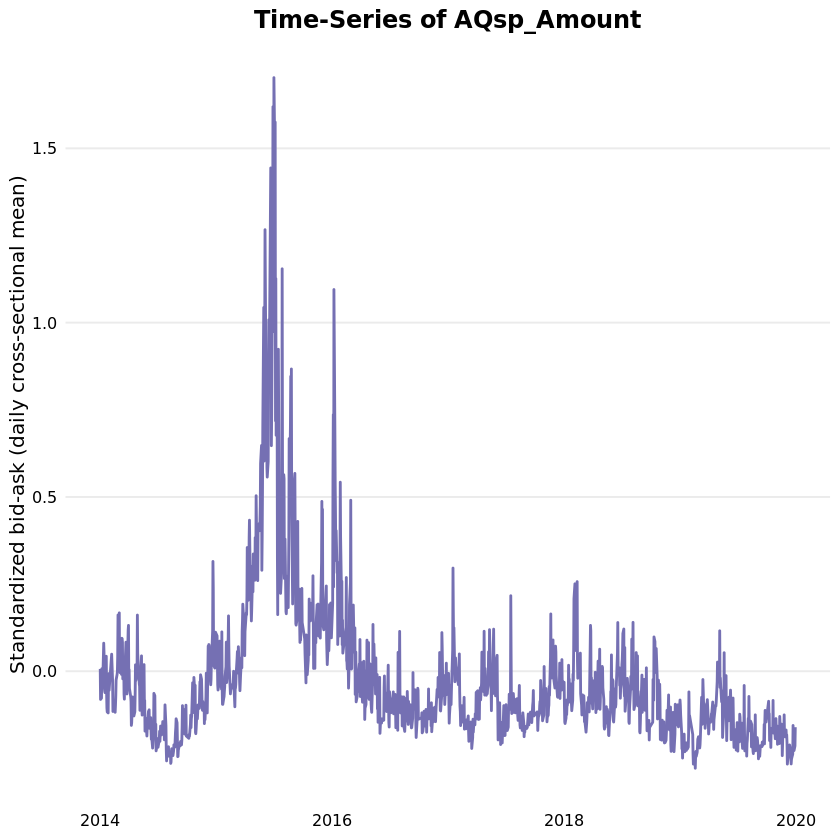

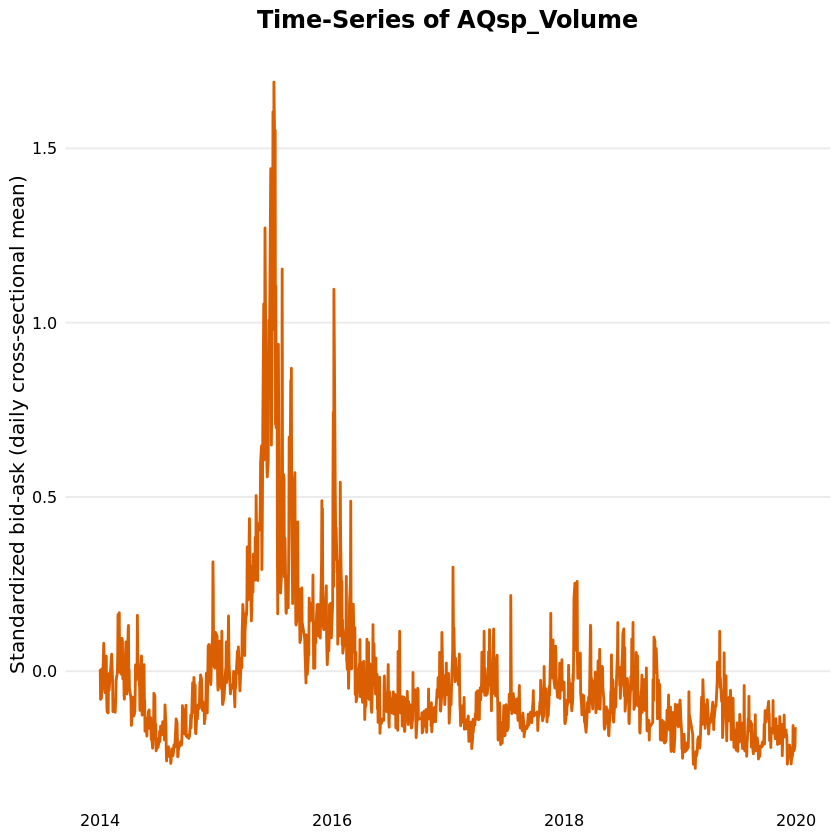

Saved 3 separate mean figures to: /root/autodl-tmp/Figure5/figures_bidask 


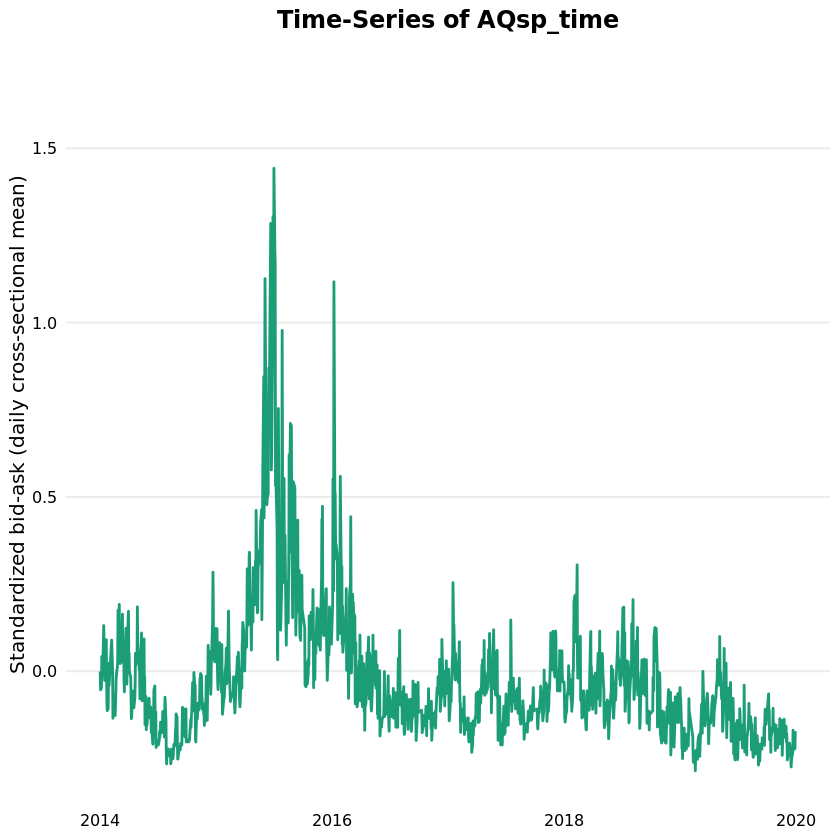

In [5]:
# ==============================
# 3) 三个指标分别画三张图（x/y轴一致 + 透明背景）——日度均值（mean）
# ==============================
# 统一的 y 轴范围（全局）
ylims <- range(long1_mean$value, na.rm = TRUE)

# 统一的 x 轴范围（全局）
xlims <- range(long1_mean$date, na.rm = TRUE)

# 三个指标名（与 long1_mean$measure 的 levels 一致）
measures <- levels(long1_mean$measure)

# 颜色（按指标固定）
col_map <- c(
  "AQsp_Amount" = "#7570B3",
  "AQsp_Volume" = "#D95F02",
  "AQsp_time"   = "#1B9E77"
)

plot_one_measure <- function(long_dt, m){
  ggplot(long_dt[measure == m], aes(x = date, y = value)) +
    geom_line(linewidth = 0.8, color = col_map[[m]]) +
    labs(
      title = paste0("Time-Series of ", m),
      x = NULL,
      y = "Standardized bid-ask (daily cross-sectional mean)"
    ) +
    scale_x_date(limits = xlims) +
    scale_y_continuous(limits = ylims) +
    theme_minimal(base_size = 12) +
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold"),
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_blank(),
      axis.text = element_text(color = "black"),
      # 关键：把 ggplot 自己画的背景也设为透明
      plot.background  = element_rect(fill = "transparent", color = NA),
      panel.background = element_rect(fill = "transparent", color = NA),
      legend.background = element_rect(fill = "transparent", color = NA),
      legend.box.background = element_rect(fill = "transparent", color = NA)
    )
}

p_amt_mean <- plot_one_measure(long1_mean, "AQsp_Amount")
p_vol_mean <- plot_one_measure(long1_mean, "AQsp_Volume")
p_tim_mean <- plot_one_measure(long1_mean, "AQsp_time")

# 预览
p_amt_mean
p_vol_mean
p_tim_mean

# ==============================
# 4) 保存 PNG（透明背景）
# ==============================
out_dir <- "/root/autodl-tmp/Figure5/figures_bidask"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

ggsave(file.path(out_dir, "Fig_Y1_AQsp_Amount_TimeSeries_Mean.png"),
       p_amt_mean, width = 7.2, height = 4.2, dpi = 300, bg = "transparent")

ggsave(file.path(out_dir, "Fig_Y1_AQsp_Volume_TimeSeries_Mean.png"),
       p_vol_mean, width = 7.2, height = 4.2, dpi = 300, bg = "transparent")

ggsave(file.path(out_dir, "Fig_Y1_AQsp_time_TimeSeries_Mean.png"),
       p_tim_mean, width = 7.2, height = 4.2, dpi = 300, bg = "transparent")

cat("Saved 3 separate mean figures to:", out_dir, "\n")

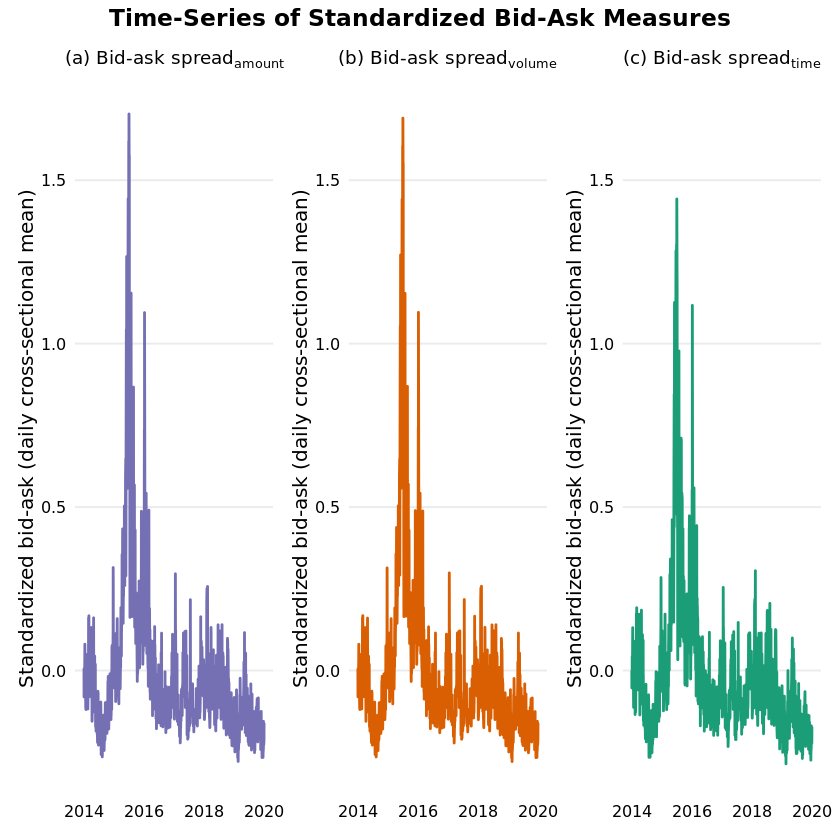

In [6]:
# ==============================
# 合并三张子图（横向并列）——Mean 版本
# ==============================
library(patchwork)

# 给三个子图加小标题（Mean）
p_amt_mean <- p_amt_mean +
  ggtitle(expression("(a) Bid-ask spread"["amount"])) +
  theme(plot.title = element_text(hjust = 0.5, size = 11, face = "bold"))

p_vol_mean <- p_vol_mean +
  ggtitle(expression("(b) Bid-ask spread"["volume"])) +
  theme(plot.title = element_text(hjust = 0.5, size = 11, face = "bold"))

p_tim_mean <- p_tim_mean +
  ggtitle(expression("(c) Bid-ask spread"["time"])) +
  theme(plot.title = element_text(hjust = 0.5, size = 11, face = "bold"))

# 横向合并 + 总标题（Mean）
p_combined_mean <- (p_amt_mean | p_vol_mean | p_tim_mean) +
  plot_annotation(
    title = "Time-Series of Standardized Bid-Ask Measures",
    theme = theme(
      plot.title = element_text(hjust = 0.5, face = "bold", size = 14)
    )
  ) &
  theme(
    #  关键：让 patchwork 外层画布也透明
    plot.background  = element_rect(fill = "transparent", color = NA),
    panel.background = element_rect(fill = "transparent", color = NA),
    legend.background = element_rect(fill = "transparent", color = NA),
    legend.box.background = element_rect(fill = "transparent", color = NA)
  )

# 显示
p_combined_mean

# 保存（透明背景）
ggsave(file.path(out_dir, "Fig_Y1_BidAsk_Combined_Mean.png"),
       p_combined_mean,
       width = 22,
       height = 7,
       dpi = 300,
       bg = "transparent")